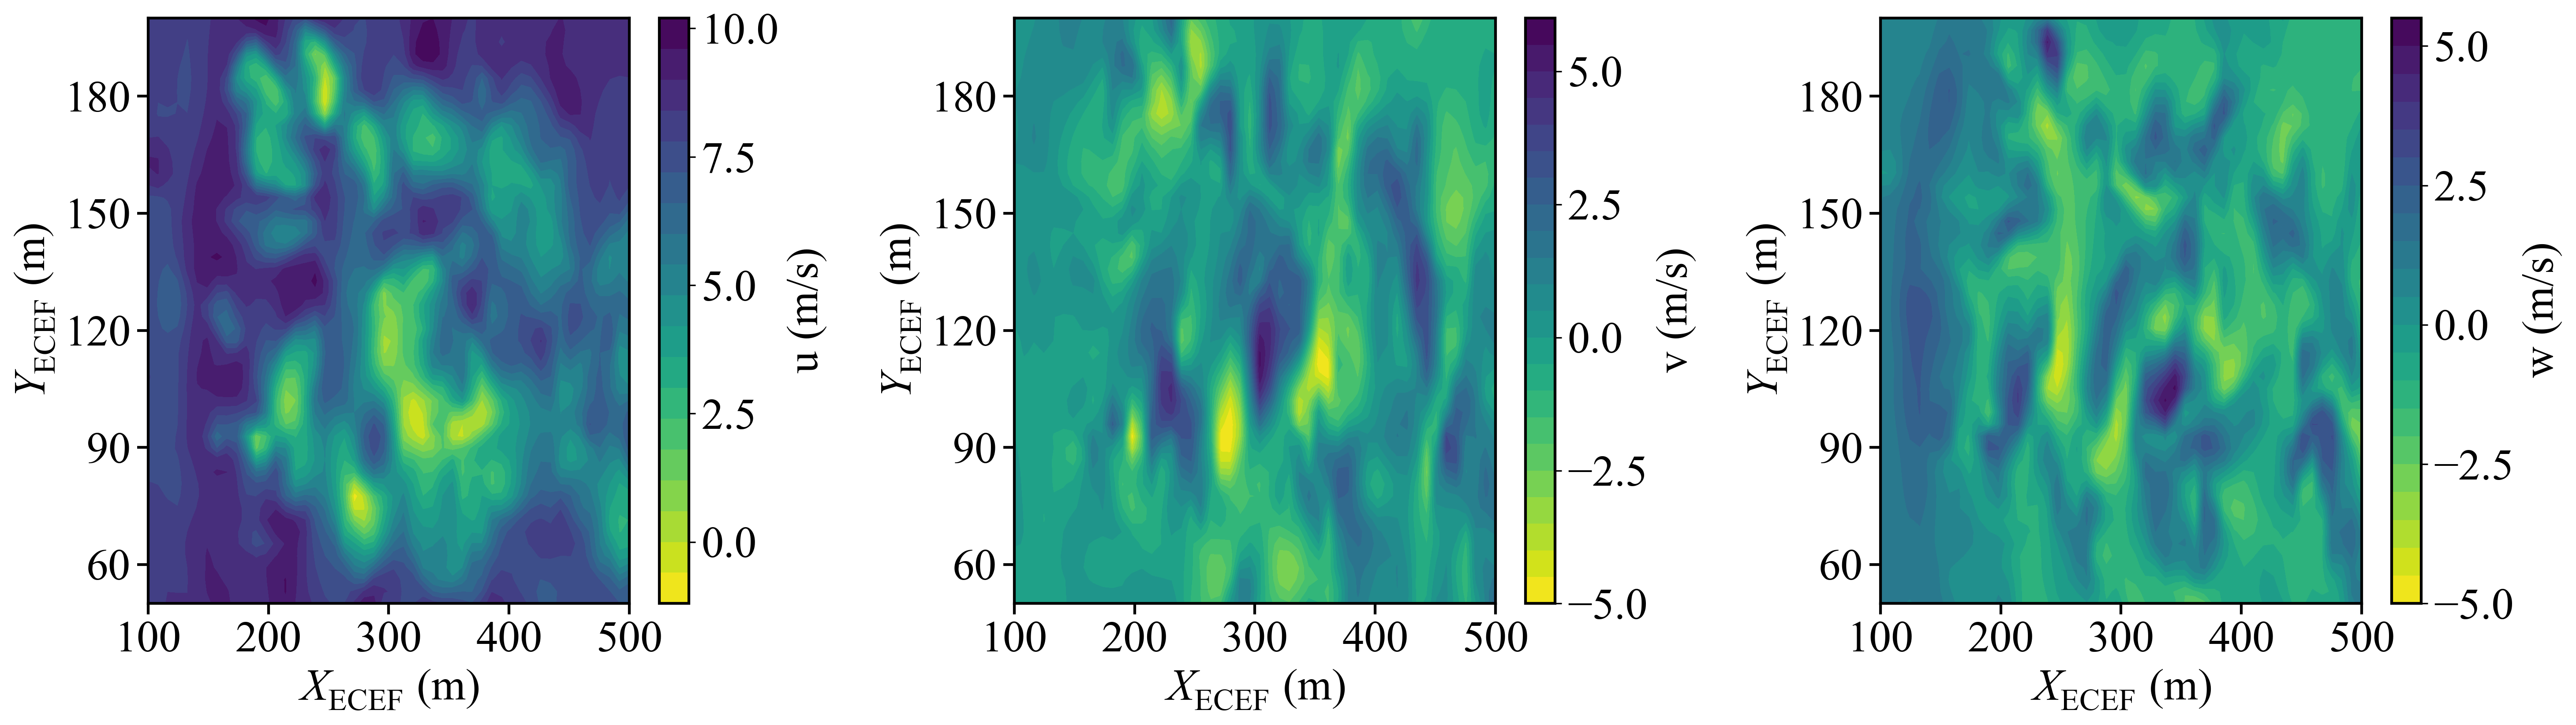

In [6]:
import pyvista as pv
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree

x_positions = np.linspace(100, 500, 50)
y_positions = np.linspace(50, 200, 50)
z_height = 50  # Reference z-height for data extraction

X, Y = np.meshgrid(x_positions, y_positions)
u_values = np.zeros_like(X)
v_values = np.zeros_like(X)
w_values = np.zeros_like(X)

mesh_bp = pv.read(r"../../wind/vtk_resampled/resampled_75.vtk")
query_yz = np.column_stack([y_positions, np.full_like(y_positions, z_height)])

for i, x_pos in enumerate(x_positions):
    clipped = mesh_bp.slice(normal='x', origin=(x_pos, 0, 0)).clip(normal=[-1, 0, 0], origin=[0, 0, 0])
    idx = cKDTree(clipped.points[:, 1:3]).query(query_yz)[1]   # nearest point (in y-z) per y
    u = clipped.get_array('U')[idx]
    u_values[:, i], v_values[:, i], w_values[:, i] = u[:, 0], u[:, 1], u[:, 2]

plt.rcParams.update({
    "font.family": "serif", "font.serif": ["Times New Roman"],
    "font.size": 24, "axes.labelsize": 24,
    "xtick.labelsize": 24, "ytick.labelsize": 24,
    "axes.linewidth": 1.5, "axes.grid": False,
    "mathtext.fontset": "custom",
    "mathtext.rm": "Times New Roman",
    "mathtext.it": "Times New Roman:italic",
})

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6), dpi=300)

components = [
    (ax1, u_values, r'u $(\mathrm{m/s})$'),
    (ax2, v_values, r'v $(\mathrm{m/s})$'),
    (ax3, w_values, r'w $(\mathrm{m/s})$'),
]

for ax, data, label in components:
    ax.tick_params(axis='both', which='major', length=6, width=1.5)
    ax.xaxis.set_major_locator(plt.LinearLocator(5))
    ax.yaxis.set_major_locator(plt.MaxNLocator(5))

    cf = ax.contourf(X, Y, data, levels=20, cmap='viridis_r')
    ax.set_xlabel(r'$X_{\mathrm{ECEF}}$ (m)')
    ax.set_ylabel(r'$Y_{\mathrm{ECEF}}$ (m)')

    cbar = plt.colorbar(cf, ax=ax)
    cbar.set_label(label)
    cbar.ax.tick_params(labelsize=24)
    cbar.locator = plt.MaxNLocator(5)
    cbar.update_ticks()

plt.tight_layout()
plt.show()